In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sales = pd.read_csv("D:\AnalytixLabs\Case Studies\Python Case Study\Case Study 4 - Python Visualizations Case Study\SalesData.csv")

In [4]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3709 entries, 0 to 3708
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   AccountId           3709 non-null   int64  
 1   AccountName         3709 non-null   object 
 2   Region              3709 non-null   object 
 3   Division            3709 non-null   object 
 4   City                3709 non-null   object 
 5   State               3709 non-null   object 
 6   Tier                3709 non-null   object 
 7   Month               3709 non-null   object 
 8   Sales2015           3709 non-null   float64
 9   Sales2016           3709 non-null   float64
 10  Units2015           3709 non-null   float64
 11  Units2016           3709 non-null   float64
 12  TargetAchevied2015  3709 non-null   float64
 13  TargetAchevied2016  3709 non-null   float64
dtypes: float64(6), int64(1), object(7)
memory usage: 405.8+ KB


In [5]:
sales.isnull().sum()

AccountId             0
AccountName           0
Region                0
Division              0
City                  0
State                 0
Tier                  0
Month                 0
Sales2015             0
Sales2016             0
Units2015             0
Units2016             0
TargetAchevied2015    0
TargetAchevied2016    0
dtype: int64

In [6]:
sales.columns

Index(['AccountId', 'AccountName', 'Region', 'Division', 'City', 'State',
       'Tier', 'Month', 'Sales2015', 'Sales2016', 'Units2015', 'Units2016',
       'TargetAchevied2015', 'TargetAchevied2016'],
      dtype='object')

In [7]:
sales_region = sales.groupby('Region')[['Sales2015', 'Sales2016']].sum()

In [8]:
sales_region

,Sales2015,Sales2016
Region,,
Central,7.891729e+06,9.787809e+06
East,9.512916e+06,1.266723e+07
West,5.349745e+06,7.209689e+06


In [9]:
sales

,AccountId,AccountName,Region,Division,City,State,Tier,Month,Sales2015,Sales2016,Units2015,Units2016,TargetAchevied2015,TargetAchevied2016
0,1116,Account1,West,DIAMONDBACK,PHOENIX W,AZ,Low,Aug,0.00,13208.52,0.0,4.0,0.70,1.53
1,1116,Account1,West,DIAMONDBACK,PHOENIX W,AZ,Low,Oct,10500.78,23114.91,3.0,7.0,0.84,1.31
2,2391,Account2,East,MINUTEMEN,HARTFORD,CT,Med,Jun,0.00,6627.00,0.0,3.0,1.15,1.29
3,2391,Account2,East,MINUTEMEN,HARTFORD,CT,Med,Mar,19881.00,13254.00,9.0,6.0,1.33,1.17
4,2397,Account3,East,MINUTEMEN,WORCESTER,MA,Med,Sep,3684.48,0.00,1.0,0.0,1.02,1.53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3704,7576,Account2736,East,EMPIRE,SYRACUSE,NY,Out,Feb,3684.48,0.00,1.0,0.0,1.06,1.14
3705,4969,Account2740,Central,SOUTHERN STAR,MONTGOMERY,AL,Med,Aug,3684.48,0.00,1.0,0.0,0.96,1.11
3706,2850,Account2746,East,SYNERGY,ASHEVILLE,NC,High,Nov,5067.70,0.00,2.0,0.0,1.11,1.55
3707,1102265,Account2748,West,DIAMONDBACK,SCOTTSDALE,AZ,Out,Jan,3684.48,0.00,1.0,0.0,1.31,1.48


In [10]:
sales_long = sales_region.stack().reset_index()

In [11]:
sales_long

,Region,level_1,0
0,Central,Sales2015,7.891729e+06
1,Central,Sales2016,9.787809e+06
2,East,Sales2015,9.512916e+06
3,East,Sales2016,1.266723e+07
4,West,Sales2015,5.349745e+06
5,West,Sales2016,7.209689e+06


In [12]:
sales_long.columns = ['Region', 'Year', 'Sales']

In [13]:
sales_long

,Region,Year,Sales
0,Central,Sales2015,7.891729e+06
1,Central,Sales2016,9.787809e+06
2,East,Sales2015,9.512916e+06
3,East,Sales2016,1.266723e+07
4,West,Sales2015,5.349745e+06
5,West,Sales2016,7.209689e+06


In [14]:
sales_long['Year'] = sales_long['Year'].str.replace('Sales', '')

In [15]:
sales_long  

,Region,Year,Sales
0,Central,2015,7.891729e+06
1,Central,2016,9.787809e+06
2,East,2015,9.512916e+06
3,East,2016,1.266723e+07
4,West,2015,5.349745e+06
5,West,2016,7.209689e+06


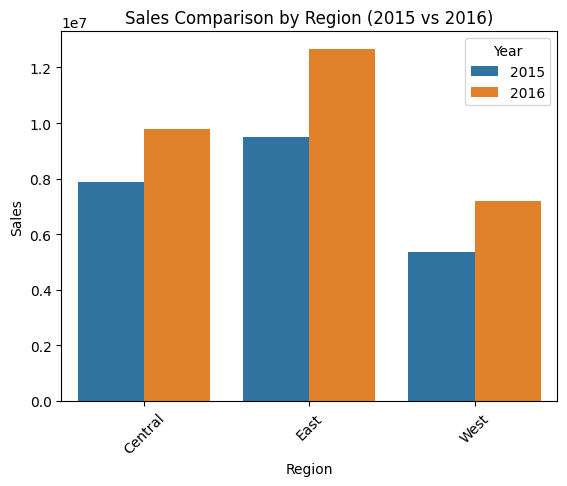

In [16]:
sns.barplot(data=sales_long, x='Region', y='Sales', hue='Year')
plt.title("Sales Comparison by Region (2015 vs 2016)")
plt.xticks(rotation=45)
plt.show()

In [17]:
# contributing factors to the sales for each region in 2016.

In [18]:
sales_2016 = sales.groupby('Region')['Sales2016'].sum()

In [19]:
sales_2016

Region
Central    9.787809e+06
East       1.266723e+07
West       7.209689e+06
Name: Sales2016, dtype: float64

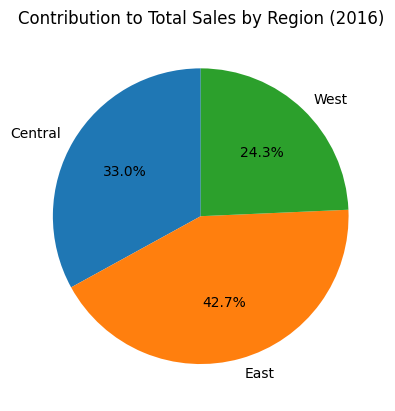

In [23]:
plt.pie(sales_2016,
        labels= sales_2016.index,
        autopct = '%1.1f%%',
        startangle=90)
plt.title("Contribution to Total Sales by Region (2016)")
plt.show()